In [1]:
%load_ext autoreload
%autoreload 2

## Requirements & Compatibility

> **scvi-tools ≥1.0 required.** spVIPESmulti targets scvi-tools 1.x and `lightning.pytorch` (was 0.20.x + `pytorch_lightning`). The deprecated `use_gpu=True` kwarg on `model.train(...)` has been **removed**; pass `accelerator="gpu", devices=1` (or `"auto"`) inside `**trainer_kwargs` instead. Minimum Python is 3.10. Several private scvi-tools modules removed in 1.x are now vendored under `spVIPESmulti.data`. See `CHANGELOG.md` for full details.

In [2]:
import numpy as np
import seaborn as sns
import scanpy as sc
import matplotlib.pyplot as plt
import spVIPESmulti

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/anndata/experimental/__init__.py:48: FutureWarning: Importing read_elem from `anndata.experimental` is deprecated. Import anndata.io.read_elem instead.
  return module_get_attr_redirect(


The dataset used in this tutorial is available at Zenodo: https://zenodo.org/records/10070301

## Preprocessing

In [3]:
simulated_data = sc.read_h5ad("data/splatter_simulation-2.h5ad")
simulated_data.var_names_make_unique()

/exports/archive/hg-funcgenom-research/mdmanurung/conda/envs/scvi-test/lib/python3.13/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


To apply spVIPESmulti we first need:

- Two datasets to learn shared / private latents from
- Annotations to use for supervision

In [4]:
# In this case we define the two datasets based on the subgroup category
simulated_data.obs['Dataset'] = simulated_data.obs.Subgroup.replace(
    {'Group1': 'Dataset 1', 'Group2': 'Dataset 1', 
     'Group3': 'Dataset 2', 'Group4': 'Dataset 2'})

/tmp/ipykernel_3184006/367976156.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  simulated_data.obs['Dataset'] = simulated_data.obs.Subgroup.replace(


In [5]:
simulated_data.obs['Celltypes'] = simulated_data.obs.Group.replace(
    {'Group1': 'Cell type 1', 'Group2': 'Cell type 2', 
     'Group3': 'Cell type 3', 'Group4': 'Cell type 4', 
     'Group5': 'Cell type 5'})

/tmp/ipykernel_3184006/2439715111.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  simulated_data.obs['Celltypes'] = simulated_data.obs.Group.replace(


To illustrate spVIPESmulti' ability to learn private variation (i.e., variation that is not shared between groups), we use the 'Subgroup' category generated with Splatter as a ground truth. 

In [6]:
simulated_data.obs['Gene_programs'] = simulated_data.obs.Subgroup.replace(
    {'Group1': 'Gene program 1a', 'Group2': 'Gene program 2a', 
     'Group3': 'Gene program 1b', 'Group4': 'Gene program 2b'})

/tmp/ipykernel_3184006/1748387903.py:1: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  simulated_data.obs['Gene_programs'] = simulated_data.obs.Subgroup.replace(


In [7]:
dataset1 = simulated_data[simulated_data.obs.Dataset == 'Dataset 1'].copy()
dataset2 = simulated_data[simulated_data.obs.Dataset == 'Dataset 2'].copy()

## spVIPESmulti preprocessing and model setup

We first need the two datasets in a single AnnData object to use as input for spVIPESmulti

In [8]:
adata = spVIPESmulti.data.prepare_adatas({"dataset_1": dataset1, "dataset_2": dataset2})

Take into account that the keys you use in the dictonary will be appended to the feature names. This is needed for spVIPESmulti' to work properly.

An spVIPESmulti model instance requires the previously generated adata together with the group and label keys.

In [16]:
spVIPESmulti.model.spVIPESmulti.setup_anndata(adata, groups_key='groups')


=== spVIPESmulti AnnData Setup ===
Setting up with groups_key: 'groups'

--- Product of Experts (PoE) Configuration ---
⚠️  No labels configured — provide label_key for PoE-based integration


In [17]:
spvipesmulti = spVIPESmulti.model.spVIPESmulti(adata, n_dimensions_private=7, n_dimensions_shared=10)

INFO     spVIPESmulti: The model has been initialized                                                              


## spVIPESmulti training

In order to train the model we need to specify the group cell indices

In [11]:
group_indices_list = [np.where(adata.obs['groups'] == group)[0] for group in adata.obs['groups'].unique()]

In [18]:
import warnings
warnings.filterwarnings("ignore")
spvipesmulti.train(group_indices_list, batch_size=128, train_size=1.0)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 160/160: 100%|██████████| 160/160 [11:53<00:00,  3.67s/it, v_num=1, train_loss=5.28e+3]

`Trainer.fit` stopped: `max_epochs=160` reached.


Epoch 160/160: 100%|██████████| 160/160 [11:53<00:00,  4.46s/it, v_num=1, train_loss=5.28e+3]


spVIPESmulti inherits scvi-tools functionality like model saving or training metrics

In [19]:
spvipesmulti.save("spvipesmulti_model")

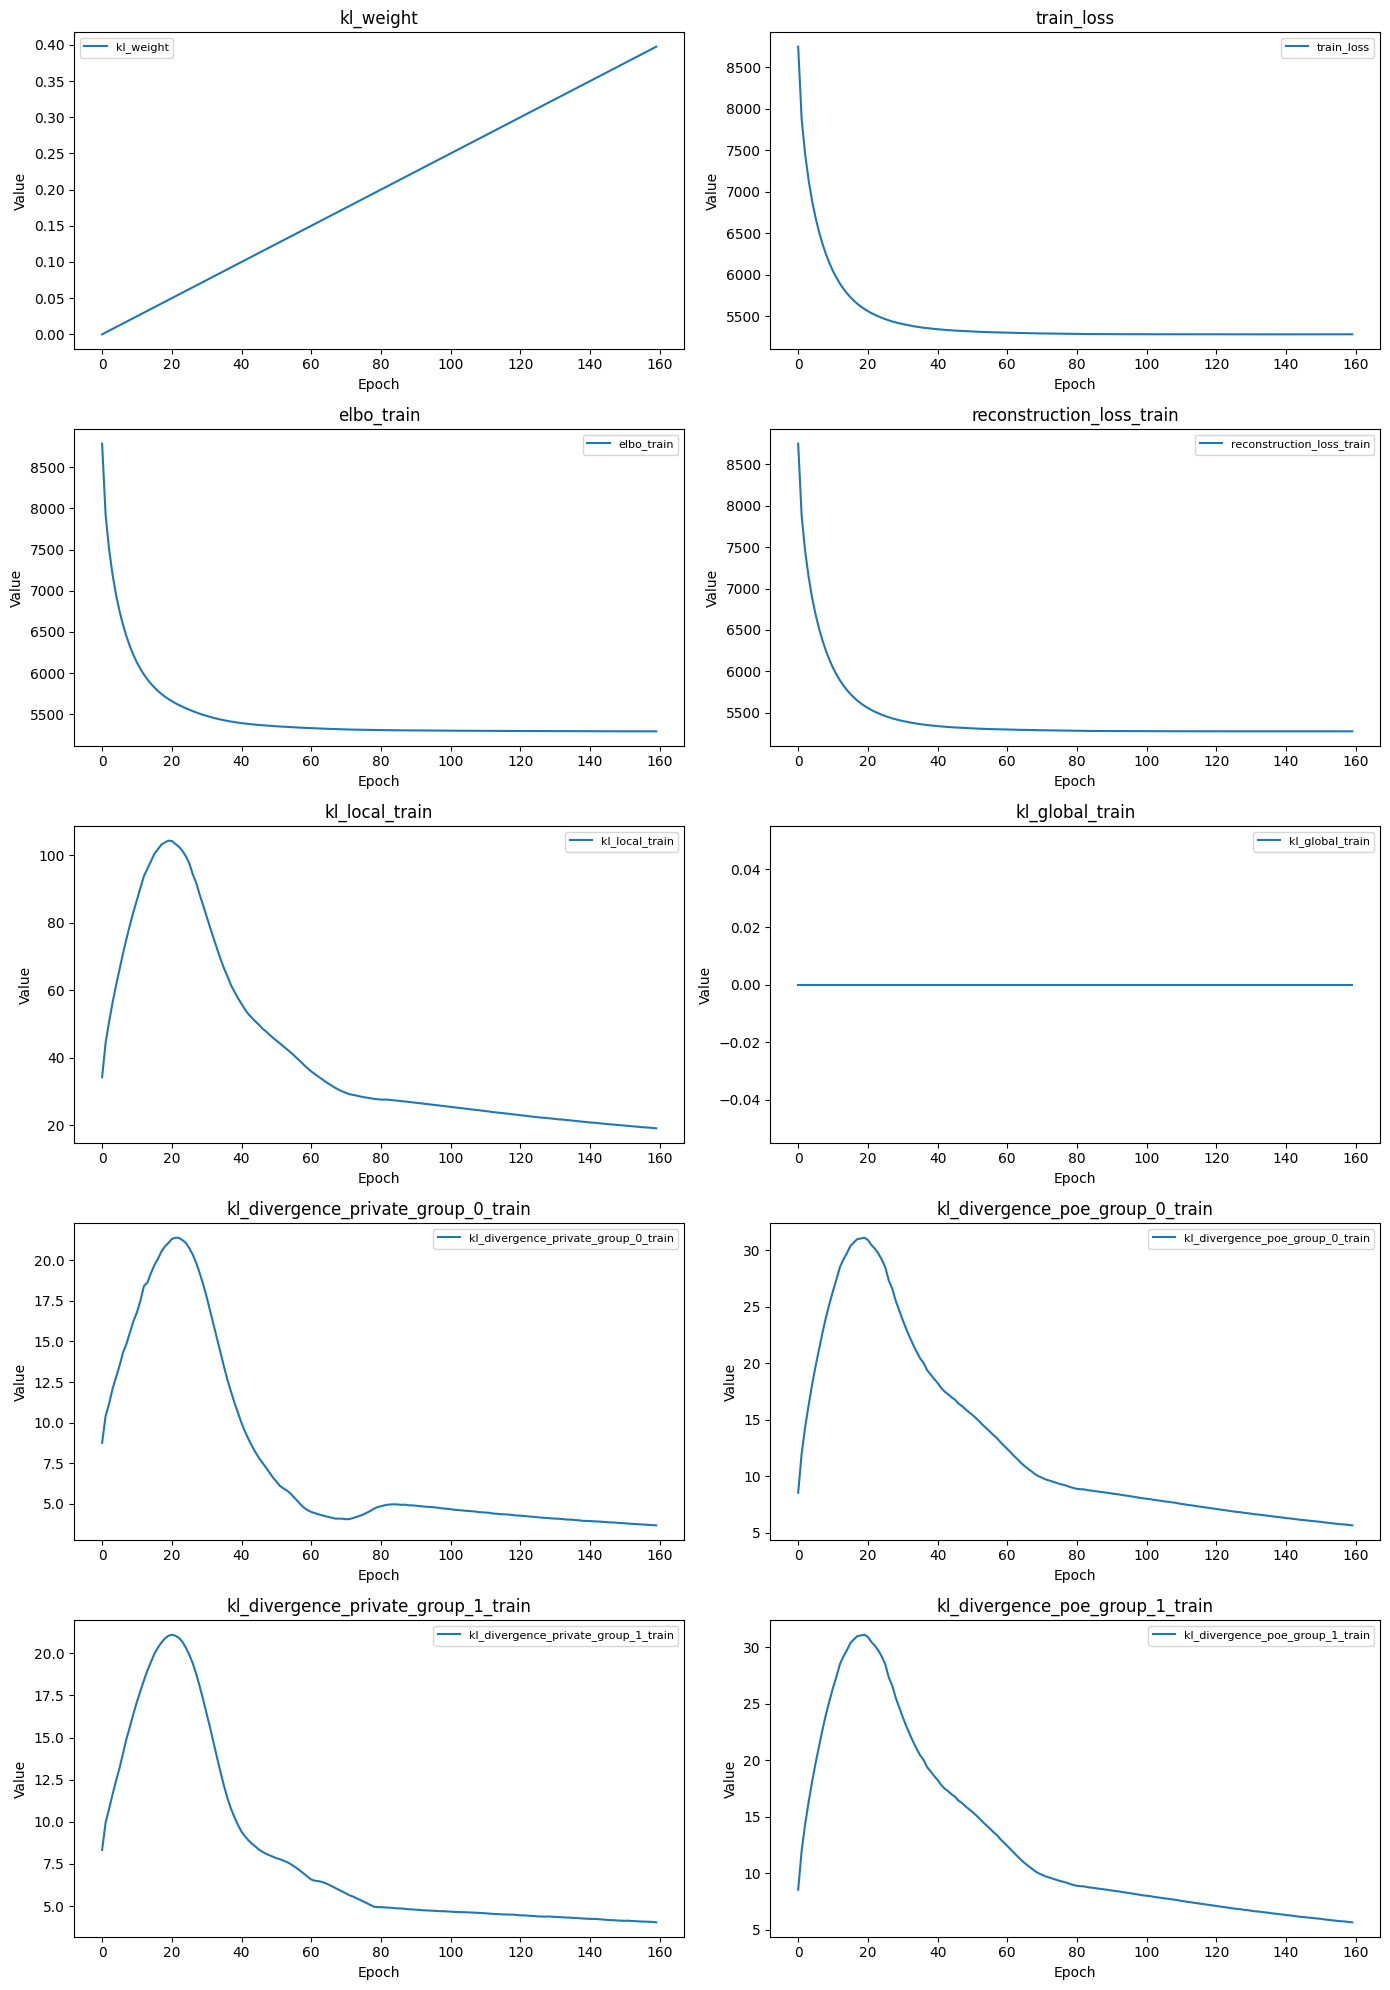

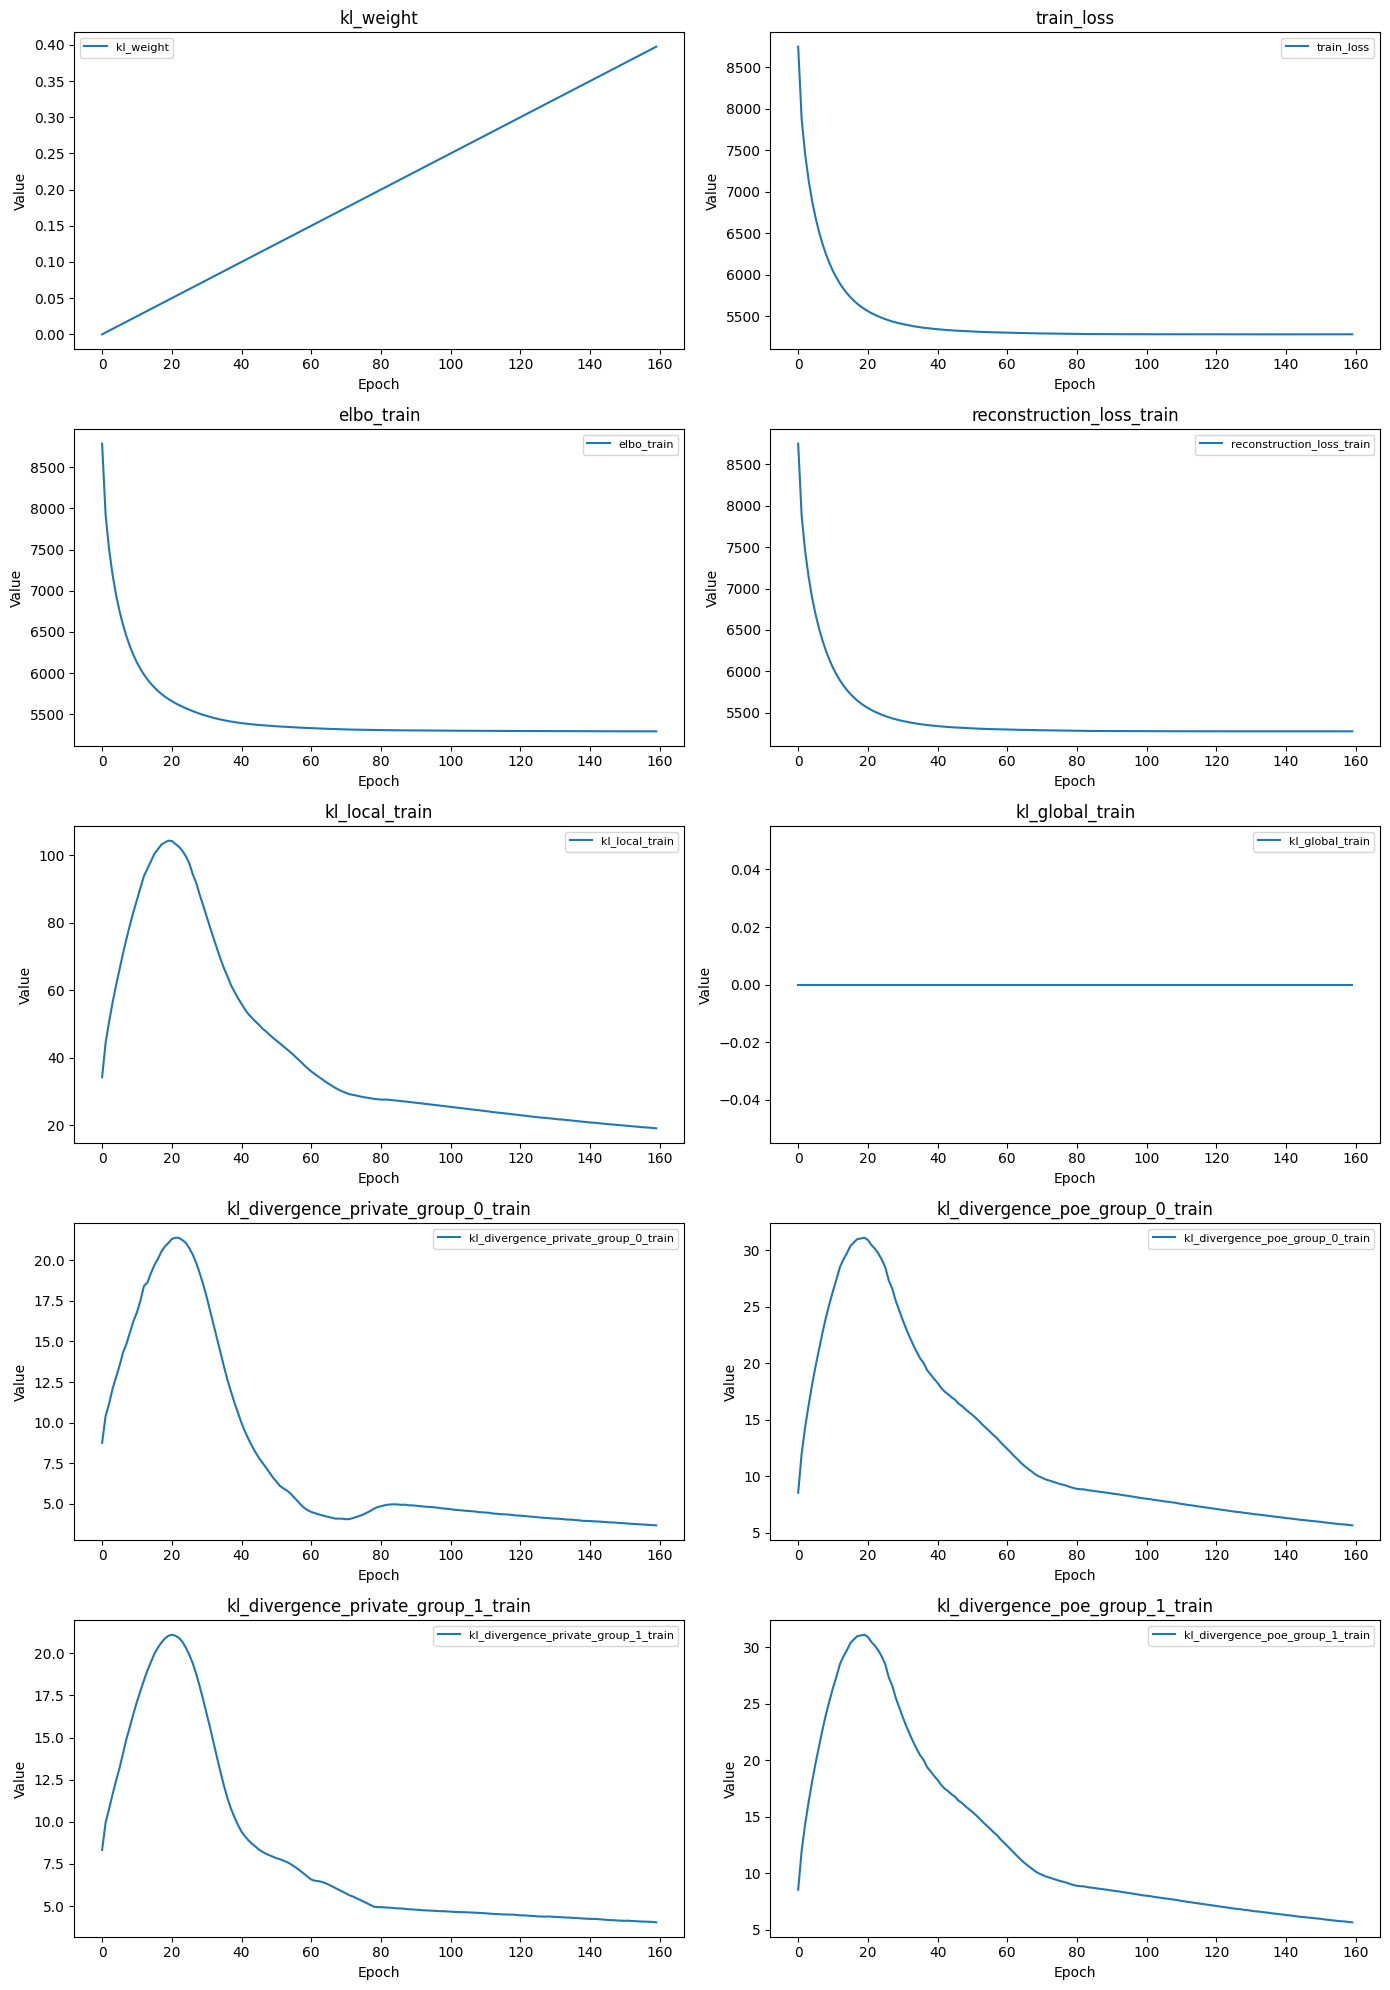

In [20]:
spVIPESmulti.pl.training_curves(spvipesmulti)

Likewise we can also load a pretrained model

In [21]:
spvipesmulti = spVIPESmulti.model.spVIPESmulti.load("spvipesmulti_model", adata=adata)

INFO     File spvipesmulti_model/model.pt already downloaded                                                       
=== spVIPESmulti AnnData Setup ===
Setting up with groups_key: 'groups'

--- Product of Experts (PoE) Configuration ---
⚠️  No labels configured — provide label_key for PoE-based integration
INFO     spVIPESmulti: The model has been initialized                                                              


In [22]:
spvipesmulti

spVIPESmulti Model with the following params: 
n_hidden: 128, n_dimensions_shared: 10, n_dimensions_private: 7, dropout_rate: 0.1, multimodal: No, nf_prior: No
Training status: Trained

## Latent space retrieval and visualizaton

spVIPESmulti outputs three sets of latent variables: 

- 2 private latents for each of the datasets used as input
- 1 shared latent, representing shared variation between the groups

In [23]:
adata[adata.obs.groups == 'dataset_1'].obs

,Group,Subgroup,sizeFactor,Dataset,Celltypes,Gene_programs,groups,indices,_scvi_batch,_scvi_groups,_scvi_indices
Cell1-dataset_1,Group5,Group1,0.967368,Dataset 1,Cell type 5,Gene program 1a,dataset_1,0,0,0,0
Cell2-dataset_1,Group3,Group1,0.855229,Dataset 1,Cell type 3,Gene program 1a,dataset_1,1,0,0,1
Cell4-dataset_1,Group3,Group2,0.816792,Dataset 1,Cell type 3,Gene program 2a,dataset_1,2,0,0,2
Cell8-dataset_1,Group1,Group1,0.944790,Dataset 1,Cell type 1,Gene program 1a,dataset_1,3,0,0,3
Cell9-dataset_1,Group4,Group1,1.163522,Dataset 1,Cell type 4,Gene program 1a,dataset_1,4,0,0,4
...,...,...,...,...,...,...,...,...,...,...,...
Cell49994-dataset_1,Group5,Group2,1.061826,Dataset 1,Cell type 5,Gene program 2a,dataset_1,24843,0,0,24843
Cell49996-dataset_1,Group1,Group2,0.653674,Dataset 1,Cell type 1,Gene program 2a,dataset_1,24844,0,0,24844
Cell49998-dataset_1,Group1,Group1,0.816222,Dataset 1,Cell type 1,Gene program 1a,dataset_1,24845,0,0,24845
Cell49999-dataset_1,Group3,Group1,0.802152,Dataset 1,Cell type 3,Gene program 1a,dataset_1,24846,0,0,24846


In [24]:
latent = spvipesmulti.get_latent_representation(group_indices_list, batch_size=128)

In [25]:
# Store latents back into adata.obsm using original cell order
spVIPESmulti.utils.store_latents(adata, latent, group_indices_list)

# Also keep individual arrays for metrics and per-group analysis
latent_private_dataset1 = latent['private_reordered'][0]
latent_private_dataset2 = latent['private_reordered'][1]
latent_shared = latent['shared_reordered'][0]
import numpy as _np; latent_shared = _np.concatenate(
    [latent['shared_reordered'][g] for g in sorted(latent['shared_reordered'])]
)


In [26]:
# shared and private latents are now in adata.obsm:
# adata.obsm['X_spVIPESmulti_shared']   <- all cells, original order
# adata.obsm['X_spVIPESmulti_private_g0'] <- dataset 1 cells
# adata.obsm['X_spVIPESmulti_private_g1'] <- dataset 2 cells
list(adata.obsm.keys())


['X_spVIPESmulti_shared',
 'X_spVIPESmulti_private_g0',
 'X_spVIPESmulti_private_g1']

In [27]:
latent_shared.shape

(50000, 10)

In [28]:
np.save("spvipesmulti_shared_embedding.npy", latent_shared)
np.save("spvipesmulti_private_embedding_dataset1.npy", latent_private_dataset1)
np.save("spvipesmulti_private_embedding_dataset2.npy", latent_private_dataset2)

We apply standard processing to the obtained embeddings

In [29]:
# shared UMAP - already stored in adata.obsm by store_latents above
spVIPESmulti.utils.compute_shared_umap(adata, umap_key='X_umap_shared')


AnnData object with n_obs × n_vars = 50000 × 5000
    obs: 'Group', 'Subgroup', 'sizeFactor', 'Dataset', 'Celltypes', 'Gene_programs', 'groups', 'indices', '_scvi_batch', '_scvi_groups', '_scvi_indices'
    uns: 'groups_var_indices', 'groups_obs_indices', 'groups_obs_names', 'groups_obs', 'groups_lengths', 'groups_var_names', 'groups_mapping', '_scvi_uuid', '_scvi_manager_uuid', '_spvipesmulti_nn_shared', 'umap'
    obsm: 'X_spVIPESmulti_shared', 'X_spVIPESmulti_private_g0', 'X_spVIPESmulti_private_g1', 'X_umap', 'X_umap_shared'
    obsp: '_spvipesmulti_nn_shared_distances', '_spvipesmulti_nn_shared_connectivities'

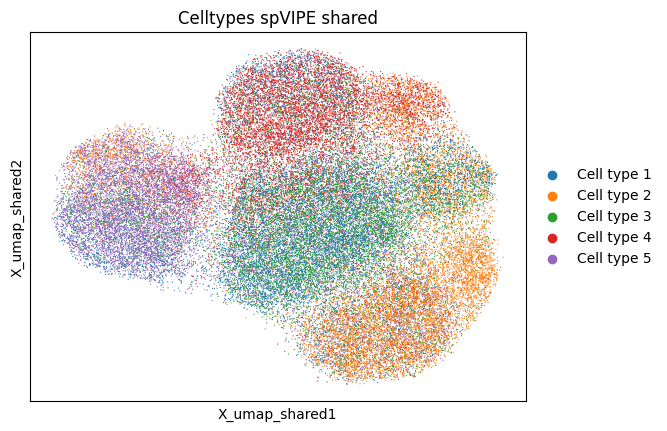

In [ ]:
sc.pl.embedding(adata, basis='X_umap_shared', color=['Celltypes'], size=3, wspace=1, 
                title='Celltypes spVIPESmulti shared')


In [31]:
# Assign private latents to per-group AnnData objects for private UMAP plots
dataset1.obsm['X_spVIPESmulti_private'] = adata[adata.obs.groups == 'dataset_1'].obsm['X_spVIPESmulti_private_g0']


In [32]:
dataset2.obsm['X_spVIPESmulti_private'] = adata[adata.obs.groups == 'dataset_2'].obsm['X_spVIPESmulti_private_g1']
spVIPESmulti.utils.compute_private_umaps(
    {'dataset_1': dataset1, 'dataset_2': dataset2},
    umap_key='X_umap_private',
)


{'dataset_1': AnnData object with n_obs × n_vars = 24848 × 2500
     obs: 'Group', 'Subgroup', 'sizeFactor', 'Dataset', 'Celltypes', 'Gene_programs', 'groups'
     var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'DEFacGroup5'
     uns: '_spvipesmulti_nn_private', 'umap'
     obsm: 'X_spVIPESmulti_private', 'X_umap', 'X_umap_private'
     obsp: '_spvipesmulti_nn_private_distances', '_spvipesmulti_nn_private_connectivities',
 'dataset_2': AnnData object with n_obs × n_vars = 25152 × 2500
     obs: 'Group', 'Subgroup', 'sizeFactor', 'Dataset', 'Celltypes', 'Gene_programs', 'groups'
     var: 'Gene', 'BaseGeneMean', 'OutlierFactor', 'GeneMean', 'DEFacGroup1', 'DEFacGroup2', 'DEFacGroup3', 'DEFacGroup4', 'DEFacGroup5'
     uns: '_spvipesmulti_nn_private', 'umap'
     obsm: 'X_spVIPESmulti_private', 'X_umap', 'X_umap_private'
     obsp: '_spvipesmulti_nn_private_distances', '_spvipesmulti_nn_private_connectivities'}

In [33]:
palette = sns.color_palette('Accent')


In [34]:
# Visualise shared and private UMAPs


In [35]:
# Private spaces should capture group-specific variation


Private spaces should learn group-specific structure (i.e., gene programs in our simulated dataset) while learning no structure shared among groups (i.e., cell types). 

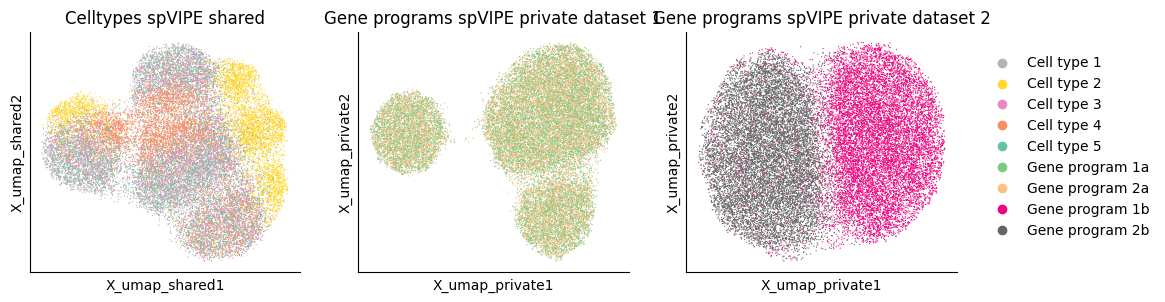

In [36]:
from operator import itemgetter
fig, axes = plt.subplots(1, 3, figsize=(10,3))
fig.tight_layout()
sc.pl.embedding(adata[adata.obs.groups == 'dataset_1'], basis='X_umap_shared', color=['Celltypes'], size=3, wspace=1, ax=axes[0], palette="Set2_r", show=False, title="Celltypes spVIPE shared")
sc.pl.embedding(dataset1, basis='X_umap_private', color=["Gene_programs"], size=3, wspace=1, ax=axes[1], palette=itemgetter(0,2)(palette), show=False, title="Gene programs spVIPE private dataset 1")
sc.pl.embedding(dataset2, basis='X_umap_private', color=["Gene_programs"], size=3, wspace=1, ax=axes[2], palette=itemgetter(5,7)(palette), show=False, title="Gene programs spVIPE private dataset 2")
sns.despine()
legends = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(item, []) for item in zip(*legends)]
for ax in axes:
    ax.get_legend().remove()
fig.legend(lines, labels, bbox_to_anchor=(1., 0.55), loc="center left", borderaxespad=0, frameon=False)
plt.show()

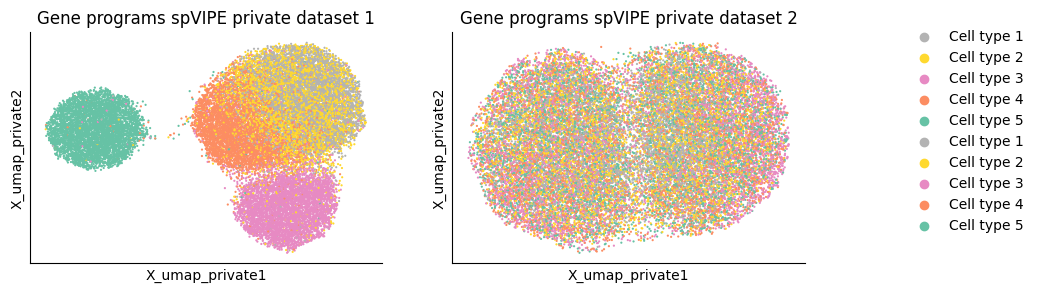

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10,3))
sc.pl.embedding(dataset1, basis='X_umap_private', color=["Celltypes"], size=10, wspace=1, palette="Set2_r", show=False, ax=axes[0], title="Gene programs spVIPE private dataset 1")
sc.pl.embedding(dataset2, basis='X_umap_private', color=["Celltypes"], size=10, wspace=1,  palette="Set2_r", show=False, ax=axes[1], title="Gene programs spVIPE private dataset 2")
sns.despine()
legends = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(item, []) for item in zip(*legends)]
for ax in axes:
    ax.get_legend().remove()
fig.legend(lines, labels, bbox_to_anchor=(1., 0.55), loc="center left", borderaxespad=0, frameon=False)
plt.show()

Qualitatively, the shared and private latent spaces learned by spVIPESmulti capture shared and dataset-specific variation, respectively, but the private spaces do not capture shared variation for any of the datasets

## Disentanglement objective (group-only configuration)

spVIPESmulti supports an optional **disentanglement objective** (inspired by
CellDISECT and Multi-ContrastiveVAE) that explicitly enforces:

* `z_shared` should be **uninformative about group identity**
* `z_private` should be **informative about group identity**

Realised through 4 auxiliary classifiers (2 adversarial, 2 supervised)
plus an optional InfoNCE on the shared latent.

**This tutorial does not register cell-type labels** (`label_key`), so
the label-using components (`q_label_shared`, `q_label_private`,
contrastive) cannot be enabled — they would raise a `ValueError`.
We enable only the **group classifiers** here:

| Component | Latent | Target | Role |
|---|---|---|---|
| `q_group_shared` | z_shared | group | erase group identity (adversarial via GRL) |
| `q_group_private` | z_private | group | preserve group identity (supervised CE) |

See `disentangle_ablation.ipynb` for a full ablation walkthrough on a
labelled dataset.

In [38]:
spvipesmulti_dis = spVIPESmulti.model.spVIPESmulti(
    adata,
    n_dimensions_private=7, n_dimensions_shared=10,
    disentangle_group_shared_weight=1.0,
    disentangle_group_private_weight=1.0,
)
spvipesmulti_dis.train(group_indices_list, max_epochs=400, n_epochs_kl_warmup=400)


INFO     spVIPESmulti: The model has been initialized                                                              


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Epoch 8/400:   2%|▏         | 7/400 [00:56<52:29,  8.01s/it, v_num=1, train_loss=6.65e+3]


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

In [ ]:
latent_dis = spvipesmulti_dis.get_latent_representation(group_indices_list, batch_size=128)

# Build a flat shared array (all cells, original order) for metrics and UMAP
import numpy as _np
latent_shared_dis = _np.concatenate(
    [latent_dis['shared_reordered'][g] for g in sorted(latent_dis['shared_reordered'])]
)
print('shared_dis shape:', latent_shared_dis.shape)


### Compare baseline vs disentanglement-enabled model

We attach the disentanglement-enabled embeddings to the AnnData and
compute UMAPs for the shared latent. With group adversarial enabled,
the shared latent should mix dataset_1 and dataset_2 cells more thoroughly
while still preserving cell-type structure — and the private latent for
each dataset should retain dataset-specific signal.

In [ ]:
adata.obsm['X_spVIPESmulti_shared_dis'] = latent_shared_dis
spVIPESmulti.utils.compute_shared_umap(adata, obsm_key='X_spVIPESmulti_shared_dis', umap_key='X_umap_shared_dis')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, basis, title in zip(
    axes,
    ['X_umap_shared', 'X_umap_shared_dis'],
    ['baseline', 'disentangle group-only'],
):
    sc.pl.embedding(adata, basis=basis, color='groups', ax=ax,
                    show=False, title=f'shared / {title}', size=3)
plt.tight_layout(); plt.show()


Heuristic check — k-NN group-mixing in `z_shared` (higher = better mixing):

In [ ]:
import pandas as pd

groups_arr = adata.obs['groups'].values
pd.DataFrame({
    'group_mixing_shared (higher=better)': [
        spVIPESmulti.metrics.kbet(latent_shared, groups_arr),
        spVIPESmulti.metrics.kbet(latent_shared_dis, groups_arr),
    ]
}, index=['baseline', 'disentangle group-only'])
